# Analyse historique : Nappe phréatique + Précipitations (2015-2026)

## Contexte

Ce notebook étend l'analyse croisée nappe/pluie sur la période **2015-2026** pour fournir un contexte historique à l'épisode « hors de contrôle » de janvier-février 2026.

Les données piézométriques proviennent de l'API Hub'eau et sont **cachées localement** année par année dans `_data/`.

### Piézomètres
- **Blagon** (Lanton) — code BSS [`08262X0023/F`](https://ades.eaufrance.fr/Fiche/PtEau?Code=BSS001ZDUB#mesures_graphiques)
- **Piraillan** (Lège-Cap-Ferret) — code BSS `08257X0086/F`

### Station météo
- **Cap-Ferret** — données Météo-France (Gironde)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

from siba import (
    PIEZOMETERS,
    fetch_nappe_multi_years,
    load_meteo_capferret,
    merge_nappe_pluie,
)

plt.style.use('seaborn-v0_8-whitegrid')

YEARS = range(2010, 2027)
DATE_MIN = '2010-01-01'



# ---------------------------------------------------------------------------
# Périodes « hors de contrôle » du réseau EU — SIBA / Bassin d'Arcachon
#
# verified=True  → date confirmée par arrêté préfectoral ou constat OFB officiel
# verified=False → date estimée / rapportée par lanceurs d'alerte ou presse
# ---------------------------------------------------------------------------
HC_PERIODS = [
    # ── 2014 ────────────────────────────────────────────────────────────────
    {
        'start':    pd.Timestamp('2014-01-24'),
        'end':      pd.Timestamp('2014-03-12'),
        'label':    'HC 2014 (hiver — dates approx.)',
        'communes': ['Bassin d\'Arcachon (général)'],
        'cause':    'Saturation réseau EU par pluies hivernales',
        'source':   'D Lafon',
        'verified': True,   # dates exactes non retrouvées dans les sources officielles
    },
    # ── 2016 ────────────────────────────────────────────────────────────────
    {
        'start':    pd.Timestamp('2016-01-5'),
        'end':      pd.Timestamp('2016-01-14'),
        'label':    'HC Janv 2016 (hiver — dates approx.)',
        'communes': ['Bassin d\'Arcachon (général)'],
        'cause':    'Saturation réseau EU par pluies hivernales',
        'source':   'D Lafon',
        'verified': True,   # dates exactes non retrouvées dans les sources officielles
    },
    {
        'start':    pd.Timestamp('2016-02-9'),
        'end':      pd.Timestamp('2016-02-17'),
        'label':    'HC Fev 2016 (hiver — dates approx.)',
        'communes': ['Bassin d\'Arcachon (général)'],
        'cause':    'Saturation réseau EU par pluies hivernales',
        'source':   'D Lafon',
        'verified': True,   # dates exactes non retrouvées dans les sources officielles
    },
    {
        'start':    pd.Timestamp('2016-03-4'),
        'end':      pd.Timestamp('2016-03-11'),
        'label':    'HC Mars 2016 (hiver — dates approx.)',
        'communes': ['Bassin d\'Arcachon (général)'],
        'cause':    'Saturation réseau EU par pluies hivernales',
        'source':   'D Lafon',
        'verified': True,   # dates exactes non retrouvées dans les sources officielles
    },    
    # ── 2020 ────────────────────────────────────────────────────────────────
    {
        'start':    pd.Timestamp('2020-11-01'),
        'end':      pd.Timestamp('2020-12-31'),
        'label':    'HC 2020 (hiver — dates approx.)',
        'communes': ['Bassin d\'Arcachon (général)'],
        'cause':    'Saturation réseau EU par pluies hivernales — norovirus signalé',
        'source':   'Ostréiculteurs / CRCAA (mention rétrospective)',
        'verified': False,   # dates exactes non retrouvées dans les sources officielles
    },
    # ── 2021 ────────────────────────────────────────────────────────────────
    {
        'start':    pd.Timestamp('2021-02-08'),   # date des dernières récoltes retirées
        'end':      pd.Timestamp('2021-03-15'),   # ~28 j après l'AP, estimé
        'label':    'HC 2021 (fév.→mars)',
        'communes': ['Bassin d\'Arcachon (général)'],
        'cause':    'Intempéries hivernales — saturation réseau — norovirus',
        'source':   'France Bleu Gironde / AP préfectoral ~18 fév. 2021',
        'verified': True,    # arrêté préfectoral ~18 fév. 2021 confirmé (France Bleu)
    },
    # ── 2023 ────────────────────────────────────────────────────────────────
    {
        'start':    pd.Timestamp('2023-11-10'),
        'end':      pd.Timestamp('2023-12-31'),
        'label':    'HC 2023 (15/10→31/12)',
        'communes': ['Andernos', 'Lanton', 'Arès', 'Gujan-Mestras', 'La Teste',
                     'Audenge'],
        'cause':    '24 j consécutifs de pluie (18 mm/j moy.) ; bassin Titoune déborde '
                    'vers ruisseau Masurat → Bassin',
        'source':   'ADEBA / Le Bétey / Préfecture Gironde',
        'verified': True,    # constat lanceur d'alerte nov. 2023 + AP 27 déc. 2023
    },
    # ── 2024 ────────────────────────────────────────────────────────────────
    {
        'start':    pd.Timestamp('2024-02-22'),  
        'end':      pd.Timestamp('2024-04-01'),   # constat OFB le 1er avril
        'label':    'HC 2024 (22/02→01/04)',
        'communes': ['Lanton', 'Taussat', 'Andernos', 'Arès', 'Gujan-Mestras',
                     'La Teste'],
        'cause':    'surverses littorales constatées par l\'OFB '
                    'le 1er avril 2024',
        'source':   'Rapport annuel SB2A/SIBA 2024 · OFB · Le Bétey',
        'verified': True,    # constat officiel OFB 01/04/2024
    },
    # ── 2026 ────────────────────────────────────────────────────────────────
    {
        'start':    pd.Timestamp('2026-01-21'),   # date déclarée par Veolia
        'end':      pd.Timestamp('2026-02-25'),   
        'label':    'HC 2026 (21/01→25/02)',
        'communes': ['Lanton', 'Taussat'],
        'cause':    'Janv. 2026 : +55 % pluie vs normale (15e mois le plus pluvieux '
                    'depuis 1949) ; nappes hautes ; bassins de sécu pleins ; '
                    'débordements station de relevage Taussat constatés le 5 fév. 2026',
        'source':   'AFP / France Bleu Gironde / La Gazette France (fév. 2026)',
        'verified': True,    # constat journalistes AFP sur site le 05/02/2026
    },
]

# ---------------------------------------------------------------------------
# Périodes d'interdiction préfectorale de pêche/commercialisation des coquillages
# Bassin d'Arcachon + Banc d'Arguin
#
# verified=True  → arrêté préfectoral explicitement daté dans les sources
# verified=False → période estimée ou partiellement documentée
# ---------------------------------------------------------------------------
INTERDICTION_PERIODS = [
    # ── 2020 ────────────────────────────────────────────────────────────────
    {
        'start':        pd.Timestamp('2020-11-01'),  # estimé — hiver 2020
        'end':          pd.Timestamp('2020-12-15'),  # estimé (~28 j, période peu sensible)
        'label':        'Interdiction 2020 (hiver — dates approx.)',
        'especes':      ['huîtres', 'coquillages'],
        'cause':        'Norovirus (origine EU)',
        'peche_loisir': True,
        'source':       'Mention rétrospective CRCAA / ostréiculteurs',
        'verified':     False,
    },
    # ── 2021 ────────────────────────────────────────────────────────────────
    {
        'start':        pd.Timestamp('2021-02-18'),  # AP ~18 fév. 2021
        'end':          pd.Timestamp('2021-03-18'),  # ~28 j
        'label':        'Interdiction 2021 (18/02→~18/03)',
        'especes':      ['huîtres', 'coques', 'moules', 'pétoncles'],
        'cause':        'Norovirus (origine EU) — toxi-infections collectives',
        'peche_loisir': True,
        'source':       'France Bleu Gironde — AP préfectoral ~18 fév. 2021',
        'verified':     True,
    },
    # ── mai 2023 (toxines algales — NON lié aux EU) ──────────────────────
    {
        'start':        pd.Timestamp('2023-05-17'),
        'end':          pd.Timestamp('2023-06-15'),  # estimé — levée non datée précisément
        'label':        'Interdiction 2023 mai (17/05→~mi-juin) — toxines algales',
        'especes':      ['moules', 'palourdes', 'coques'],   # huîtres NON concernées
        'cause':        'Toxines lipophiles (Dinophysis) — PAS lié aux EU',
        'peche_loisir': True,
        'source':       'Préfecture Gironde — AP 17/05/2023 (site officiel)',
        'verified':     True,
    },
    # ── déc. 2023 / jan. 2024 (crise majeure) ────────────────────────────
    {
        'start':        pd.Timestamp('2023-12-27'),
        'end':          pd.Timestamp('2024-01-19'),  # levée le 19 jan. 2024 à 9h
        'label':        'Interdiction 2023-2024 (27/12→19/01) ⚠ CRISE MAJEURE',
        'especes':      ['huîtres', 'palourdes', 'moules', 'coques',
                         'tous coquillages Bassin + Banc d\'Arguin'],
        'cause':        'Norovirus (origine EU) — épidémie gastro-entérite '
                        '25-26 déc. 2023 ; surverses massives réseau SIBA',
        'peche_loisir': True,
        'source':       'AP préfectoral 27/12/2023 · Levée AP 18/01/2024 (Préfecture Gironde)',
        'verified':     True,
    },
]

## 1. Chargement des données

Récupération de toutes les données piézométriques 2015-2026 (avec cache local) et des précipitations Météo-France.

In [2]:
nappe_data = {}
for p in PIEZOMETERS:
    nappe_data[p['name']] = fetch_nappe_multi_years(
        p['code_bss'], p['name'], years=YEARS
    )

for name, df in nappe_data.items():
    if len(df) > 0:
        print(f"\n{name} : {df['date_mesure'].min().date()} → {df['date_mesure'].max().date()}")
        print(f"  Profondeur : {df['profondeur_nappe'].min():.2f} m → {df['profondeur_nappe'].max():.2f} m")

Récupération multi-années : Blagon (Lanton) (08262X0023/F)
  Cache → Blagon (Lanton) (08262X0023/F) année 2026 (âge 1.4 h)
  Total : 6066 mesures (2010-01-01 → 2026-09-11)
Récupération multi-années : Piraillan (Lège-Cap-Ferret) (08257X0086/F)
  Cache → Piraillan (Lège-Cap-Ferret) (08257X0086/F) année 2026 (âge 1.5 h)
  Total : 5821 mesures (2010-08-09 → 2026-09-11)

Blagon (Lanton) : 2010-01-01 → 2026-09-11
  Profondeur : 0.75 m → 2.77 m

Piraillan (Lège-Cap-Ferret) : 2010-08-09 → 2026-09-11
  Profondeur : 2.51 m → 4.28 m


In [3]:
df_meteo = load_meteo_capferret(date_min=DATE_MIN)
df_meteo.head()

  Archive figée : /home/yml/Dropbox/Devs/siba_dataviz/_data/Q_33_previous-1950-2024_RR-T-Vent.csv.gz


  À jour (1.3 h) : /home/yml/Dropbox/Devs/siba_dataviz/_data/Q_33_latest-2025-2026_RR-T-Vent.csv.gz
Fichiers CSV météo : ['/home/yml/Dropbox/Devs/siba_dataviz/_data/Q_33_1842-1949_RR-T-Vent.csv', '/home/yml/Dropbox/Devs/siba_dataviz/_data/Q_33_latest-2025-2026_RR-T-Vent.csv', '/home/yml/Dropbox/Devs/siba_dataviz/_data/Q_33_previous-1950-2024_RR-T-Vent.csv']


Cap-Ferret : 2010-01-01 → 2026-09-11  (6098 jours)


,NUM_POSTE,NOM_USUEL,LAT,LON,ALTI,AAAAMMJJ,RR,QRR,TN,QTN,...,QFXI3S,DXI3S,QDXI3S,HXI3S,QHXI3S,DRR,QDRR,STATUS_FXI3S,STATUS_DXI3S,SLIDING_RR7
DATE,,,,,,,,,,,,,,,,,,,,,
2010-01-01,33236002,CAP-FERRET,44.6305,-1.251667,8,20100101,10.0,1.0,6.7,1.0,...,NaN,NaN,NaN,NaN,NaN,179.0,9.0,NaN,NaN,29.4
2010-01-02,33236002,CAP-FERRET,44.6305,-1.251667,8,20100102,0.2,1.0,2.1,1.0,...,1.0,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,29.4
2010-01-03,33236002,CAP-FERRET,44.6305,-1.251667,8,20100103,5.2,1.0,3.3,1.0,...,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,NaN,25.6
2010-01-04,33236002,CAP-FERRET,44.6305,-1.251667,8,20100104,0.0,1.0,4.0,1.0,...,NaN,NaN,NaN,NaN,NaN,0.0,9.0,NaN,NaN,23.2
2010-01-05,33236002,CAP-FERRET,44.6305,-1.251667,8,20100105,0.2,1.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,3.0,9.0,NaN,NaN,22.4


In [4]:
df_merged = merge_nappe_pluie(nappe_data, df_meteo, date_min=DATE_MIN)
print(f"DataFrame fusionné : {len(df_merged)} jours, colonnes : {list(df_merged.columns)}")
print(f"\nDonnées manquantes :")
print(df_merged.isnull().sum())
df_merged.tail()

DataFrame fusionné : 6098 jours, colonnes : ['Blagon', 'Piraillan', 'RR', 'SLIDING_RR7']

Données manquantes :
Blagon          21
Piraillan      265
RR               0
SLIDING_RR7      0
dtype: int64


,Blagon,Piraillan,RR,SLIDING_RR7
date,,,,
2026-09-07,2.77,4.25,0.0,0.0
2026-09-08,2.77,4.27,0.2,0.2
2026-09-09,2.77,4.27,0.2,0.4
2026-09-10,2.77,4.28,0.0,0.4
2026-09-11,2.77,4.28,0.0,0.4


## 2. Vue d'ensemble multi-années

Small multiples : un sous-graphe par année montrant la nappe (axe gauche) et le RR7 (axe droit).

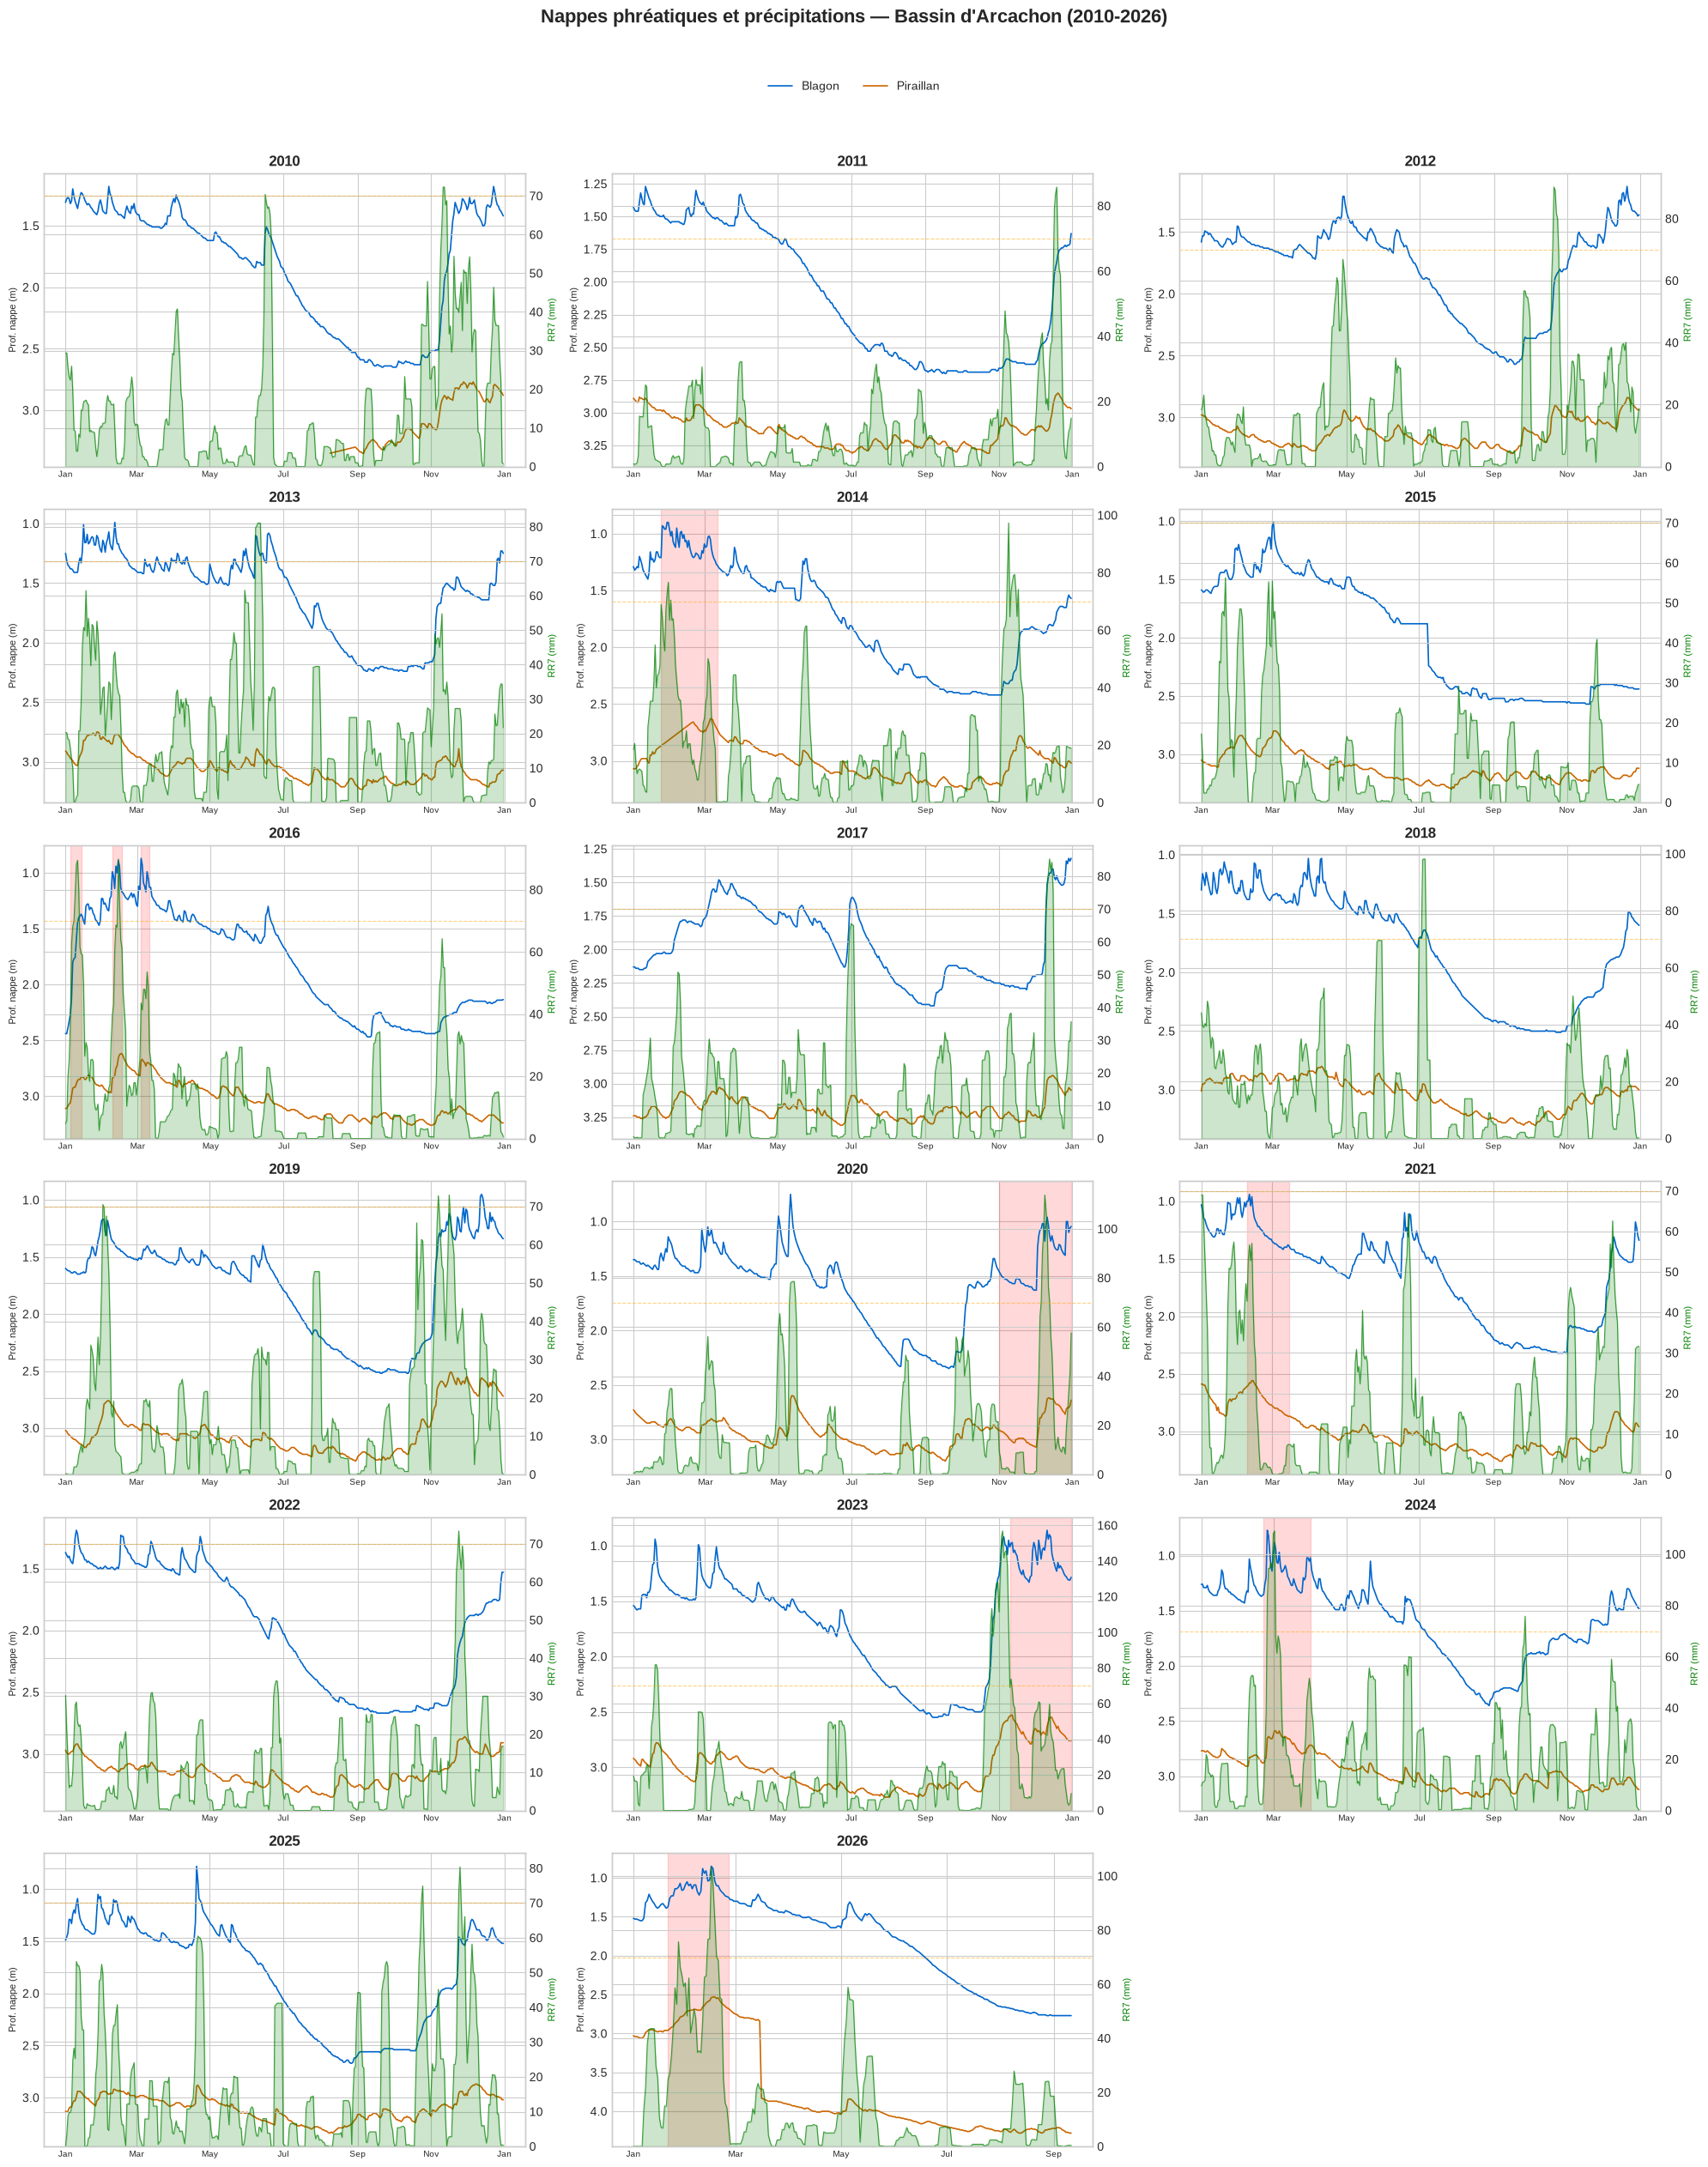

In [5]:
nappe_cols = [c for c in df_merged.columns if c not in ['RR', 'SLIDING_RR7']]
colors_nappe = ['#0066cc', '#cc6600']

years_list = sorted(set(df_merged.index.year))
n_years = len(years_list)
n_cols = 3
n_rows = (n_years + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows), sharex=False)
axes_flat = axes.flatten()

for i, year in enumerate(years_list):
    ax = axes_flat[i]
    mask = df_merged.index.year == year
    df_year = df_merged.loc[mask]

    # Nappe (axe gauche)
    for j, col in enumerate(nappe_cols):
        data = df_year[col].dropna()
        if len(data) > 0:
            ax.plot(data.index, data.values, color=colors_nappe[j % len(colors_nappe)],
                    linewidth=1.2, label=col)
    ax.invert_yaxis()
    ax.set_ylabel('Prof. nappe (m)', fontsize=8)

    # RR7 (axe droit)
    ax2 = ax.twinx()
    rr7 = df_year['SLIDING_RR7'].dropna()
    if len(rr7) > 0:
        ax2.fill_between(rr7.index, 0, rr7.values, alpha=0.2, color='green')
        ax2.plot(rr7.index, rr7.values, color='green', linewidth=0.8, alpha=0.7)
    ax2.axhline(y=70, color='orange', linestyle='--', linewidth=0.8, alpha=0.5)
    ax2.set_ylabel('RR7 (mm)', fontsize=8, color='green')
    ax2.set_ylim(bottom=0)

    # Périodes « hors de contrôle »
    for hc in HC_PERIODS:
        if hc['start'].year == year or hc['end'].year == year:
            ax.axvspan(max(hc['start'], df_year.index.min()),
                       min(hc['end'], df_year.index.max()),
                       alpha=0.15, color='red')

    ax.set_title(str(year), fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.tick_params(axis='x', labelsize=7)

# Masquer les axes vides
for i in range(n_years, len(axes_flat)):
    axes_flat[i].set_visible(False)

# Légende commune
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(nappe_cols), fontsize=10,
           bbox_to_anchor=(0.5, 1.02))

fig.suptitle(f'Nappes phréatiques et précipitations — Bassin d\'Arcachon ({years_list[0]}-{years_list[-1]})',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 3. Statistiques annuelles — Nappe phréatique

Profondeur minimale, moyenne, et nombre de jours sous différents seuils par année.

In [6]:
stats_nappe = []
for year in years_list:
    mask = df_merged.index.year == year
    df_year = df_merged.loc[mask]
    row = {'Année': year}
    for col in nappe_cols:
        data = df_year[col].dropna()
        if len(data) > 0:
            row[f'{col} min (m)'] = data.min()
            row[f'{col} moy (m)'] = data.mean()
            row[f'{col} max (m)'] = data.max()
            # Jours avec nappe < percentile 10 historique (nappe haute)
            p10 = df_merged[col].dropna().quantile(0.10)
            row[f'{col} jours < P10 ({p10:.2f}m)'] = int((data < p10).sum())
    stats_nappe.append(row)

df_stats_nappe = pd.DataFrame(stats_nappe).set_index('Année')
display(df_stats_nappe.style.format('{:.2f}', subset=[c for c in df_stats_nappe.columns if 'jours' not in c])
        .background_gradient(cmap='RdYlGn', axis=0,
                             subset=[c for c in df_stats_nappe.columns if 'min' in c]))

,Blagon min (m),Blagon moy (m),Blagon max (m),Blagon jours < P10 (1.27m),Piraillan min (m),Piraillan moy (m),Piraillan max (m),Piraillan jours < P10 (2.84m)
Année,,,,,,,,
2010,1.18,1.84,2.65,13,2.77,3.08,3.35,24
2011,1.27,2.10,2.70,0,2.85,3.14,3.31,0
2012,1.13,1.78,2.57,11,2.84,3.13,3.29,0
2013,0.99,1.60,2.24,55,2.75,3.05,3.23,30
2014,0.90,1.74,2.42,63,2.63,3.02,3.25,48
2015,1.01,2.00,2.57,17,2.80,3.12,3.30,5
2016,0.87,1.83,2.47,41,2.62,3.05,3.26,48
2017,1.32,1.96,2.42,0,2.94,3.19,3.31,0
2018,1.03,1.78,2.51,45,2.80,3.04,3.30,7


## 4. Statistiques annuelles — Précipitations

Cumul annuel, max RR7, nombre de jours au-dessus du seuil SIBA de 70 mm/7j.

In [7]:
stats_pluie = []
for year in years_list:
    mask = df_merged.index.year == year
    df_year = df_merged.loc[mask]
    rr = df_year['RR'].dropna()
    rr7 = df_year['SLIDING_RR7'].dropna()
    row = {
        'Année': year,
        'Cumul annuel (mm)': rr.sum() if len(rr) > 0 else np.nan,
        'RR max journalier (mm)': rr.max() if len(rr) > 0 else np.nan,
        'RR7 max (mm)': rr7.max() if len(rr7) > 0 else np.nan,
        'Jours RR7 > 70mm': int((rr7 > 70).sum()) if len(rr7) > 0 else 0,
        'Jours RR7 > 50mm': int((rr7 > 50).sum()) if len(rr7) > 0 else 0,
    }
    stats_pluie.append(row)

df_stats_pluie = pd.DataFrame(stats_pluie).set_index('Année')
display(df_stats_pluie.style.format('{:.1f}', subset=[c for c in df_stats_pluie.columns if 'Jours' not in c])
        .background_gradient(cmap='Blues', axis=0,
                             subset=['Cumul annuel (mm)', 'RR7 max (mm)']))

,Cumul annuel (mm),RR max journalier (mm),RR7 max (mm),Jours RR7 > 70mm,Jours RR7 > 50mm
Année,,,,,
2010,698.4,29.9,72.3,3,18
2011,535.1,21.9,85.8,3,7
2012,743.7,36.2,90.2,5,21
2013,950.1,44.9,81.1,5,18
2014,888.1,33.0,97.3,11,32
2015,510.8,17.9,56.3,0,3
2016,721.9,26.1,89.9,6,22
2017,716.2,48.8,85.3,7,14
2018,791.8,40.6,98.2,6,15


### Visualisation — Cumul annuel et jours de seuil

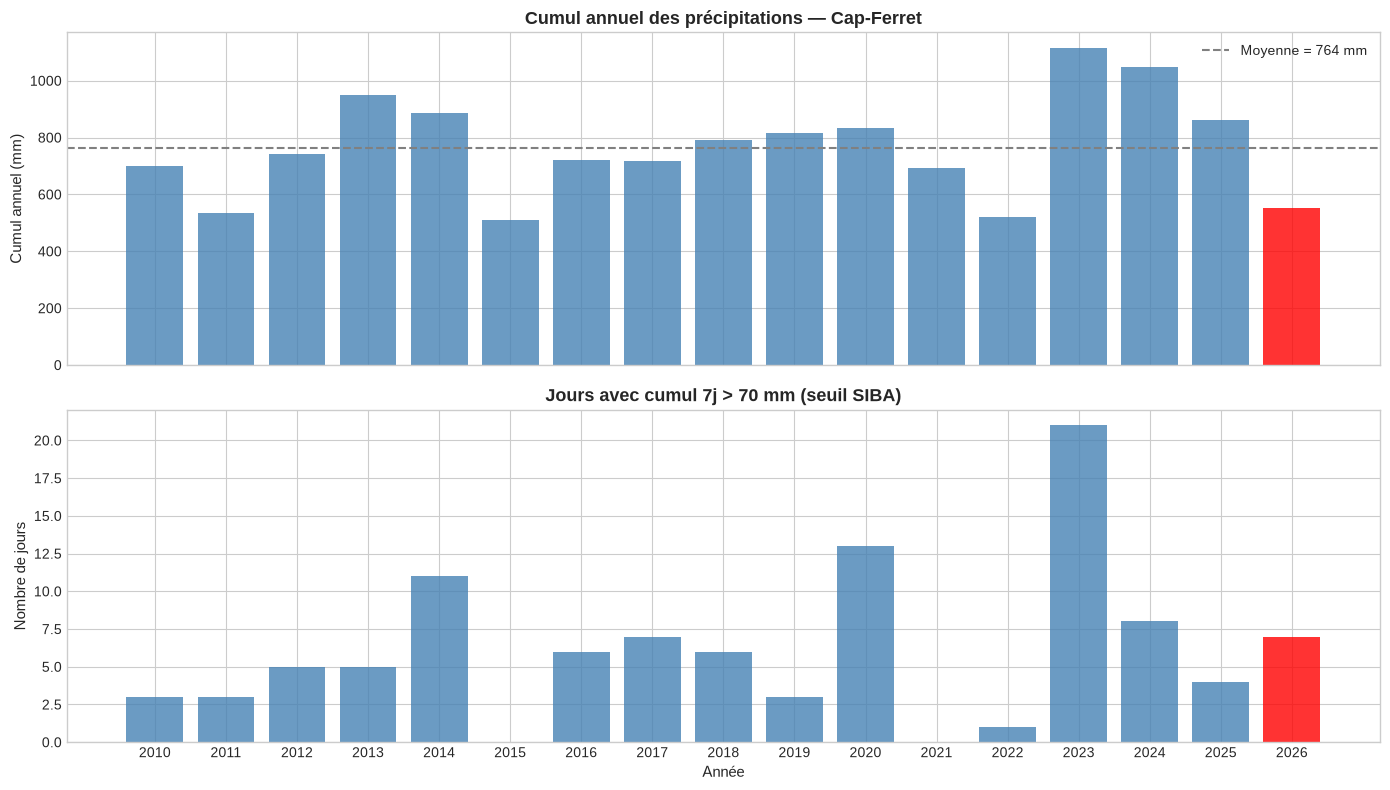

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Cumul annuel
years_str = [str(y) for y in df_stats_pluie.index]
bar_colors = ['red' if y == 2026 else 'steelblue' for y in df_stats_pluie.index]
ax1.bar(years_str, df_stats_pluie['Cumul annuel (mm)'], color=bar_colors, alpha=0.8)
ax1.axhline(df_stats_pluie['Cumul annuel (mm)'].mean(), color='gray', linestyle='--',
            label=f"Moyenne = {df_stats_pluie['Cumul annuel (mm)'].mean():.0f} mm")
ax1.set_ylabel('Cumul annuel (mm)', fontsize=11)
ax1.set_title('Cumul annuel des précipitations — Cap-Ferret', fontsize=13, fontweight='bold')
ax1.legend()

# Jours au-dessus du seuil
ax2.bar(years_str, df_stats_pluie['Jours RR7 > 70mm'], color=bar_colors, alpha=0.8)
ax2.set_ylabel('Nombre de jours', fontsize=11)
ax2.set_title('Jours avec cumul 7j > 70 mm (seuil SIBA)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Année', fontsize=11)

plt.tight_layout()
plt.show()

## 5. Cross-corrélation nappe vs RR7 par année

Comment le décalage temporel (lag) entre précipitations et réponse de la nappe varie-t-il d'une année sur l'autre ?

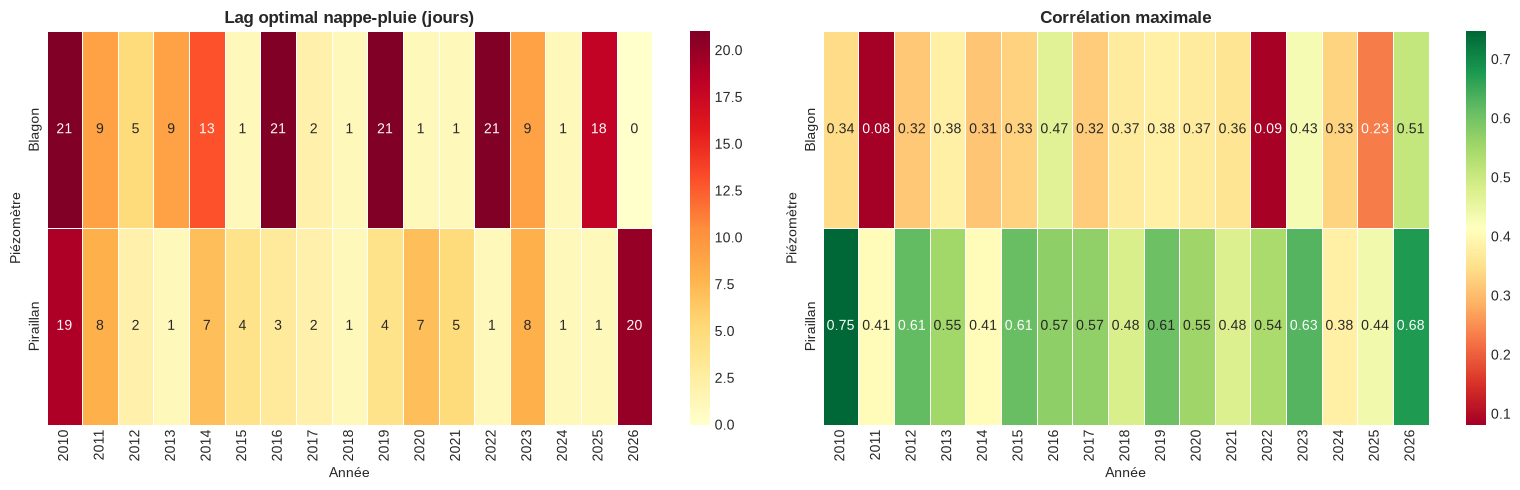

'Piézomètre  Année  Meilleur lag (j)  Corrélation max\n    Blagon   2010                21         0.342325\n    Blagon   2011                 9         0.081504\n    Blagon   2012                 5         0.315455\n    Blagon   2013                 9         0.380742\n    Blagon   2014                13         0.311146\n    Blagon   2015                 1         0.328787\n    Blagon   2016                21         0.467755\n    Blagon   2017                 2         0.321992\n    Blagon   2018                 1         0.370689\n    Blagon   2019                21         0.381289\n    Blagon   2020                 1         0.371384\n    Blagon   2021                 1         0.359327\n    Blagon   2022                21         0.085620\n    Blagon   2023                 9         0.430898\n    Blagon   2024                 1         0.332850\n    Blagon   2025                18         0.230369\n    Blagon   2026                 0         0.509223\n Piraillan   2010          

In [9]:
max_lag = 21  # jours

xcorr_results = []

for col in nappe_cols:
    for year in years_list:
        mask = df_merged.index.year == year
        df_year = df_merged.loc[mask, [col, 'SLIDING_RR7']].dropna()
        if len(df_year) < 30:
            continue

        nappe_vals = -df_year[col].values  # inverser (nappe haute = valeur haute)
        rr7_vals = df_year['SLIDING_RR7'].values

        nappe_norm = (nappe_vals - nappe_vals.mean()) / (nappe_vals.std() + 1e-10)
        rr7_norm = (rr7_vals - rr7_vals.mean()) / (rr7_vals.std() + 1e-10)

        best_r, best_lag_val = -1, 0
        for lag in range(0, max_lag + 1):
            if lag == 0:
                r = np.corrcoef(rr7_norm, nappe_norm)[0, 1]
            else:
                r = np.corrcoef(rr7_norm[:-lag], nappe_norm[lag:])[0, 1]
            if r > best_r:
                best_r = r
                best_lag_val = lag

        xcorr_results.append({
            'Piézomètre': col,
            'Année': year,
            'Meilleur lag (j)': best_lag_val,
            'Corrélation max': best_r,
        })

df_xcorr = pd.DataFrame(xcorr_results)

# Heatmap du lag par année
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title, cmap in [
    (ax1, 'Meilleur lag (j)', 'Lag optimal nappe-pluie (jours)', 'YlOrRd'),
    (ax2, 'Corrélation max', 'Corrélation maximale', 'RdYlGn'),
]:
    pivot = df_xcorr.pivot(index='Piézomètre', columns='Année', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.0f' if 'lag' in metric.lower() else '.2f',
                cmap=cmap, ax=ax, linewidths=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

display(df_xcorr.to_string(index=False))

## 6. Comparaison des épisodes « hors de contrôle »

Comparaison directe des périodes où le réseau EU a été déclaré « hors de contrôle ».

In [10]:
# Statistiques comparées des périodes HC
period_rows = []
for hc in HC_PERIODS:
    mask = (df_merged.index >= hc['start']) & (df_merged.index <= hc['end'])
    df_period = df_merged.loc[mask]

    row = {'Épisode': hc['label'], 'Durée (j)': mask.sum()}
    for col in nappe_cols:
        data = df_period[col].dropna()
        if len(data) > 0:
            row[f'{col} moy (m)'] = data.mean()
            row[f'{col} min (m)'] = data.min()
            row[f'{col} max (m)'] = data.max()

    rr7 = df_period['SLIDING_RR7'].dropna()
    if len(rr7) > 0:
        row['RR7 moy (mm)'] = rr7.mean()
        row['RR7 max (mm)'] = rr7.max()
        row['Jours RR7 > 70mm'] = int((rr7 > 70).sum())

    rr = df_period['RR'].dropna()
    if len(rr) > 0:
        row['Cumul période (mm)'] = rr.sum()

    period_rows.append(row)

df_hc_compare = pd.DataFrame(period_rows).set_index('Épisode')
display(Markdown('### Tableau comparatif des épisodes « hors de contrôle »'))
display(df_hc_compare.style
        .format('{:.2f}', subset=[c for c in df_hc_compare.columns if 'moy' in c or 'min' in c or 'max' in c.lower()])
        .format('{:.1f}', subset=[c for c in df_hc_compare.columns if 'mm)' in c and 'moy' not in c]))

### Tableau comparatif des épisodes « hors de contrôle »

,Durée (j),Blagon moy (m),Blagon min (m),Blagon max (m),Piraillan moy (m),Piraillan min (m),Piraillan max (m),RR7 moy (mm),RR7 max (mm),Jours RR7 > 70mm,Cumul période (mm)
Épisode,,,,,,,,,,,
HC 2014 (hiver — dates approx.),48,1.09,0.90,1.28,2.70,2.63,2.75,34.32,76.7,3,215.3
HC Janv 2016 (hiver — dates approx.),10,1.70,1.37,2.27,2.91,2.83,3.06,69.60,89.5,4,105.2
HC Fev 2016 (hiver — dates approx.),9,1.03,0.89,1.17,2.72,2.62,2.84,63.44,89.9,2,79.8
HC Mars 2016 (hiver — dates approx.),8,1.04,0.87,1.17,2.70,2.67,2.73,44.51,53.6,0,48.4
HC 2020 (hiver — dates approx.),61,1.36,0.96,1.63,2.86,2.62,3.07,22.90,113.8,8,231.5
HC 2021 (fév.→mars),36,1.27,0.94,1.42,2.73,2.56,2.87,12.42,57.1,0,42.8
HC 2023 (15/10→31/12),52,1.14,0.86,1.33,2.67,2.53,2.79,31.39,73.8,1,205.9
HC 2024 (22/02→01/04),40,1.14,0.77,1.35,2.70,2.59,2.88,40.67,109.1,7,248.5
HC 2026 (21/01→25/02),36,1.11,0.85,1.37,2.70,2.53,2.96,52.48,103.4,7,262.5


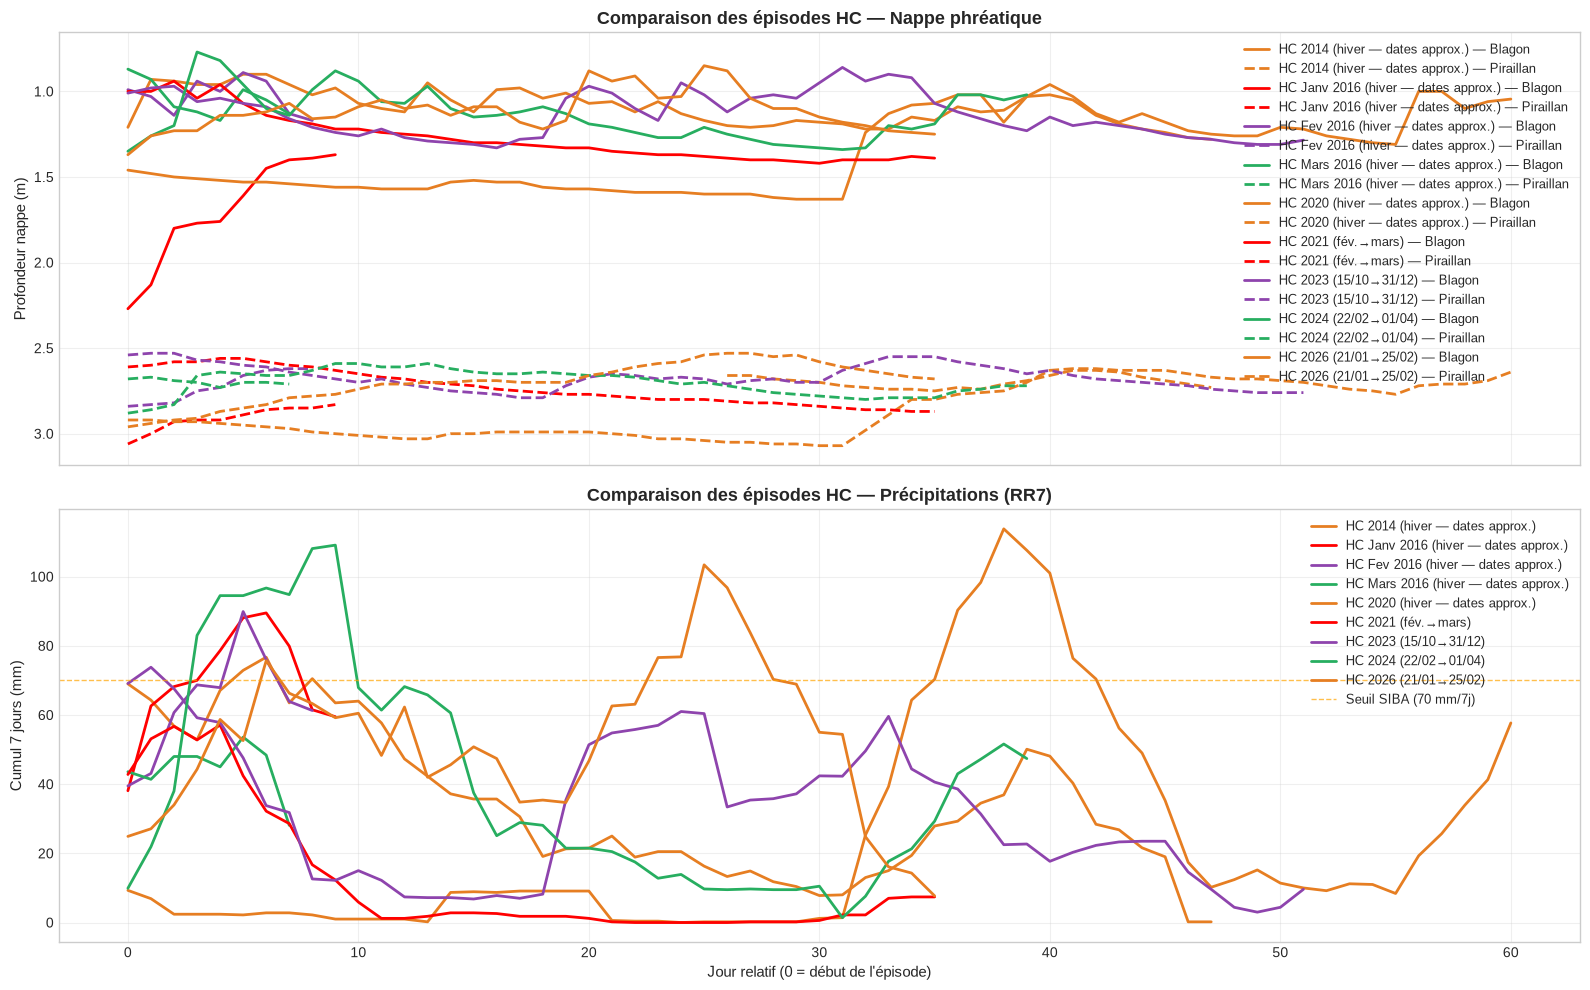

In [11]:
# Superposer les épisodes HC en alignant sur le jour relatif (jour 0 = début de l'épisode)
hc_colors = ['#e67e22', 'red', '#8e44ad', '#27ae60']

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Panel 1 : nappe
ax = axes[0]
for i, hc in enumerate(HC_PERIODS):
    mask = (df_merged.index >= hc['start']) & (df_merged.index <= hc['end'])
    df_period = df_merged.loc[mask]
    days = (df_period.index - hc['start']).days
    color = hc_colors[i % len(hc_colors)]
    for j, col in enumerate(nappe_cols):
        data = df_period[col].dropna()
        if len(data) > 0:
            d = (data.index - hc['start']).days
            ls = '-' if j == 0 else '--'
            ax.plot(d, data.values, color=color, linestyle=ls, linewidth=2,
                    label=f'{hc["label"]} — {col}')

ax.invert_yaxis()
ax.set_ylabel('Profondeur nappe (m)', fontsize=11)
ax.set_title('Comparaison des épisodes HC — Nappe phréatique', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2 : RR7
ax = axes[1]
for i, hc in enumerate(HC_PERIODS):
    mask = (df_merged.index >= hc['start']) & (df_merged.index <= hc['end'])
    df_period = df_merged.loc[mask]
    rr7 = df_period['SLIDING_RR7'].dropna()
    if len(rr7) > 0:
        d = (rr7.index - hc['start']).days
        color = hc_colors[i % len(hc_colors)]
        ax.plot(d, rr7.values, color=color, linewidth=2, label=hc['label'])

ax.axhline(y=70, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Seuil SIBA (70 mm/7j)')
ax.set_ylabel('Cumul 7 jours (mm)', fontsize=11)
ax.set_xlabel('Jour relatif (0 = début de l\'épisode)', fontsize=11)
ax.set_title('Comparaison des épisodes HC — Précipitations (RR7)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Tendance long terme

La nappe est-elle de plus en plus haute (profondeur en diminution) au fil des années ? Régression linéaire sur les moyennes annuelles.

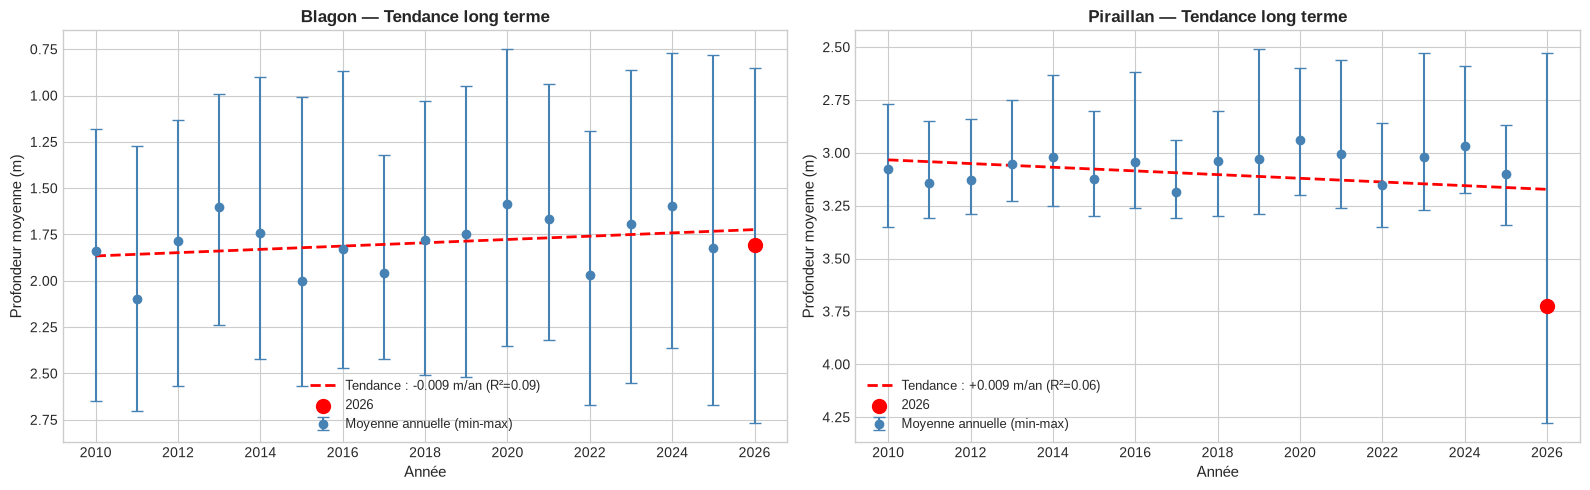

### Résultats de la régression linéaire

| Piézomètre   |   Pente (m/an) |        R² |   p-value | Tendance        |
|:-------------|---------------:|----------:|----------:|:----------------|
| Blagon       |    -0.0088857  | 0.0922767 |  0.23588  | Nappe monte ↑   |
| Piraillan    |     0.00871531 | 0.0646329 |  0.324781 | Nappe descend ↓ |

In [12]:
fig, axes = plt.subplots(1, len(nappe_cols), figsize=(8 * len(nappe_cols), 5))
if len(nappe_cols) == 1:
    axes = [axes]

trend_results = []

for ax, col in zip(axes, nappe_cols):
    annual_means = []
    for year in years_list:
        mask = df_merged.index.year == year
        data = df_merged.loc[mask, col].dropna()
        if len(data) > 30:
            annual_means.append({'year': year, 'mean': data.mean(),
                                 'min': data.min(), 'max': data.max()})

    if len(annual_means) < 3:
        ax.set_title(f'{col} — données insuffisantes')
        continue

    df_annual = pd.DataFrame(annual_means)
    x = df_annual['year'].values
    y = df_annual['mean'].values

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    trend_results.append({
        'Piézomètre': col,
        'Pente (m/an)': slope,
        'R²': r_value**2,
        'p-value': p_value,
        'Tendance': 'Nappe monte ↑' if slope < 0 else 'Nappe descend ↓',
    })

    ax.errorbar(x, y,
                yerr=[y - df_annual['min'].values, df_annual['max'].values - y],
                fmt='o', color='steelblue', capsize=4, label='Moyenne annuelle (min-max)')
    ax.plot(x, intercept + slope * x, 'r--', linewidth=2,
            label=f'Tendance : {slope:+.3f} m/an (R²={r_value**2:.2f})')

    # Mettre en évidence 2026
    mask_2026 = df_annual['year'] == 2026
    if mask_2026.any():
        ax.scatter(df_annual.loc[mask_2026, 'year'], df_annual.loc[mask_2026, 'mean'],
                   color='red', s=100, zorder=5, label='2026')

    ax.invert_yaxis()
    ax.set_xlabel('Année', fontsize=11)
    ax.set_ylabel('Profondeur moyenne (m)', fontsize=11)
    ax.set_title(f'{col} — Tendance long terme', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

if trend_results:
    df_trend = pd.DataFrame(trend_results)
    display(Markdown('### Résultats de la régression linéaire'))
    display(Markdown(df_trend.to_markdown(index=False)))

## 8. Synthèse

In [13]:
# Synthèse comparative des épisodes HC
synthese_lines = []
for _, row in df_hc_compare.iterrows():
    episode = row.name
    parts = [f"**{episode}** ({row['Durée (j)']} jours) :"]
    for col in nappe_cols:
        moy_col = f'{col} moy (m)'
        min_col = f'{col} min (m)'
        if moy_col in row.index and pd.notna(row[moy_col]):
            parts.append(f"  - {col} : moy={row[moy_col]:.2f} m, min={row[min_col]:.2f} m")
    if 'RR7 max (mm)' in row.index and pd.notna(row['RR7 max (mm)']):
        parts.append(f"  - RR7 max={row['RR7 max (mm)']:.1f} mm, "
                     f"jours > 70mm={row.get('Jours RR7 > 70mm', 0):.0f}")
    if 'Cumul période (mm)' in row.index and pd.notna(row['Cumul période (mm)']):
        parts.append(f"  - Cumul précipitations={row['Cumul période (mm)']:.0f} mm")
    synthese_lines.append('\n'.join(parts))

display(Markdown(f"""
### Comparaison des épisodes « hors de contrôle »

{chr(10).join('- ' + s for s in synthese_lines)}

---

Cette comparaison directe des épisodes HC permet d'identifier les similitudes et différences
entre les conditions hydro-météorologiques qui ont conduit à des situations « hors de contrôle »
du réseau EU.
"""))


### Comparaison des épisodes « hors de contrôle »

- **HC 2014 (hiver — dates approx.)** (48.0 jours) :
  - Blagon : moy=1.09 m, min=0.90 m
  - Piraillan : moy=2.70 m, min=2.63 m
  - RR7 max=76.7 mm, jours > 70mm=3
  - Cumul précipitations=215 mm
- **HC Janv 2016 (hiver — dates approx.)** (10.0 jours) :
  - Blagon : moy=1.70 m, min=1.37 m
  - Piraillan : moy=2.91 m, min=2.83 m
  - RR7 max=89.5 mm, jours > 70mm=4
  - Cumul précipitations=105 mm
- **HC Fev 2016 (hiver — dates approx.)** (9.0 jours) :
  - Blagon : moy=1.03 m, min=0.89 m
  - Piraillan : moy=2.72 m, min=2.62 m
  - RR7 max=89.9 mm, jours > 70mm=2
  - Cumul précipitations=80 mm
- **HC Mars 2016 (hiver — dates approx.)** (8.0 jours) :
  - Blagon : moy=1.04 m, min=0.87 m
  - Piraillan : moy=2.70 m, min=2.67 m
  - RR7 max=53.6 mm, jours > 70mm=0
  - Cumul précipitations=48 mm
- **HC 2020 (hiver — dates approx.)** (61.0 jours) :
  - Blagon : moy=1.36 m, min=0.96 m
  - Piraillan : moy=2.86 m, min=2.62 m
  - RR7 max=113.8 mm, jours > 70mm=8
  - Cumul précipitations=232 mm
- **HC 2021 (fév.→mars)** (36.0 jours) :
  - Blagon : moy=1.27 m, min=0.94 m
  - Piraillan : moy=2.73 m, min=2.56 m
  - RR7 max=57.1 mm, jours > 70mm=0
  - Cumul précipitations=43 mm
- **HC 2023 (15/10→31/12)** (52.0 jours) :
  - Blagon : moy=1.14 m, min=0.86 m
  - Piraillan : moy=2.67 m, min=2.53 m
  - RR7 max=73.8 mm, jours > 70mm=1
  - Cumul précipitations=206 mm
- **HC 2024 (22/02→01/04)** (40.0 jours) :
  - Blagon : moy=1.14 m, min=0.77 m
  - Piraillan : moy=2.70 m, min=2.59 m
  - RR7 max=109.1 mm, jours > 70mm=7
  - Cumul précipitations=248 mm
- **HC 2026 (21/01→25/02)** (36.0 jours) :
  - Blagon : moy=1.11 m, min=0.85 m
  - Piraillan : moy=2.70 m, min=2.53 m
  - RR7 max=103.4 mm, jours > 70mm=7
  - Cumul précipitations=262 mm

---

Cette comparaison directe des épisodes HC permet d'identifier les similitudes et différences
entre les conditions hydro-météorologiques qui ont conduit à des situations « hors de contrôle »
du réseau EU.
